In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import openpyxl

In [9]:
df=pd.read_excel('C:/customer-churn-mlops/data/Telco_customer_churn.xlsx')
pd.set_option("display.max_rows", None)
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [10]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [11]:
df.shape

(7043, 33)

In [17]:
df['Churn Score']

0        86
1        67
2        86
3        84
4        89
5        78
6       100
7        92
8        77
9        97
10       74
11       66
12       65
13       70
14       90
15       82
16       69
17       81
18       96
19       87
20       70
21       86
22       66
23       88
24       86
25       75
26       67
27       87
28       76
29       95
30       99
31       80
32       76
33       76
34       66
35       73
36       94
37       86
38       75
39      100
40       83
41       80
42       99
43       81
44       95
45       86
46       73
47       94
48       94
49       98
50       71
51       76
52       67
53       82
54       81
55       66
56       81
57       85
58       86
59       77
60       75
61       65
62       99
63       96
64       84
65       83
66       81
67       73
68       69
69       80
70       65
71       68
72       97
73       80
74       83
75       98
76       80
77       85
78       69
79       69
80       81
81       73
82       83
83  

In [ ]:



null=df.isnull().sum()
print(null)



CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64


In [33]:
def get_null_values(df):
    null_values=pd.DataFrame({
        "Column Name":df.columns,
        "Null_count": df.isnull().sum().values
    })
    return null_values[null_values['Null_count']>0]

In [34]:
get_null_values(df)

,Column Name,Null_count
32,Churn Reason,5174


In [35]:
df.drop(columns='Churn Reason',inplace=True)

In [36]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV'],
      dtype='object')

In [47]:
cat_cols = df.select_dtypes(include="object").columns.tolist()

num_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print(f"Categorical Features: {len(cat_cols)}")
print(f"Numerical Features: {len(num_cols)}")

print("\nCategorical Columns:")
print(cat_cols)

print("\nNumerical Columns:")
print(num_cols)

Categorical Features: 22
Numerical Features: 10

Categorical Columns:
['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Churn Label']

Numerical Columns:
['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value', 'Churn Score', 'CLTV']


In [46]:
df['Total Charges']=pd.to_numeric(df['Total Charges'],errors='coerce')

In [48]:
df.nunique().sort_values()

Count                   1
Country                 1
State                   1
Phone Service           2
Paperless Billing       2
Churn Value             2
Dependents              2
Partner                 2
Senior Citizen          2
Churn Label             2
Gender                  2
Device Protection       3
Contract                3
Streaming Movies        3
Streaming TV            3
Tech Support            3
Online Backup           3
Multiple Lines          3
Internet Service        3
Online Security         3
Payment Method          4
Tenure Months          73
Churn Score            85
City                 1129
Monthly Charges      1585
Longitude            1651
Zip Code             1652
Lat Long             1652
Latitude             1652
CLTV                 3438
Total Charges        6530
CustomerID           7043
dtype: int64

In [50]:
pd.DataFrame({
    "Unique Values":df.nunique().values,
    "columns":df.columns

})

,Unique Values,columns
0,7043,CustomerID
1,1,Count
2,1,Country
3,1,State
4,1129,City
5,1652,Zip Code
6,1652,Lat Long
7,1652,Latitude
8,1651,Longitude
9,2,Gender


## 3 out of every 4 customers stay
## 1 out of every 4 customers leave

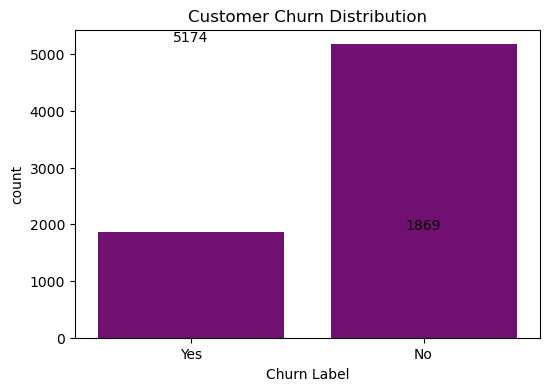

In [ ]:
churn_counts = df["Churn Label"].value_counts()

plt.figure(figsize=(6,4))
sns.countplot(x="Churn Label", data=df,color='Purple')

for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 50, str(v), ha='center')

plt.title("Customer Churn Distribution")
plt.show()

### Churn Distribution

- 73.46% customers retained.
- 26.54% customers churned.
- Dataset is moderately imbalanced.
- Accuracy alone will not be a reliable evaluation metric.
- Precision, Recall, F1-Score and ROC-AUC should be considered during model evaluation.

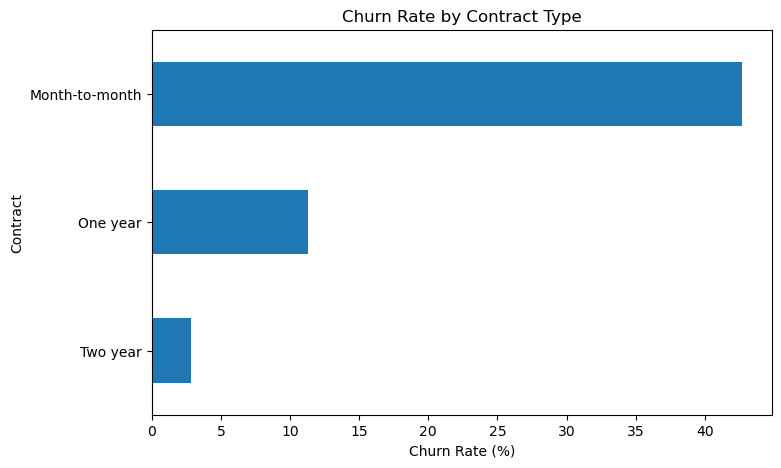

In [53]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
) * 100

contract_churn["Yes"].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.xlabel("Churn Rate (%)")
plt.title("Churn Rate by Contract Type")
plt.show()

### Contract Type vs Churn Analysis

- Customers on Month-to-Month contracts exhibit the highest churn rate (~43%).
- Customers on One-Year contracts show significantly lower churn (~11%).
- Customers on Two-Year contracts have the lowest churn rate (~3%).

Business Insight:
Long-term contracts improve customer retention significantly.
Customers with short-term commitments are more likely to switch providers.

Recommendation:
The company should encourage Month-to-Month customers to migrate to annual or multi-year plans through discounts, loyalty rewards, and bundled offers.

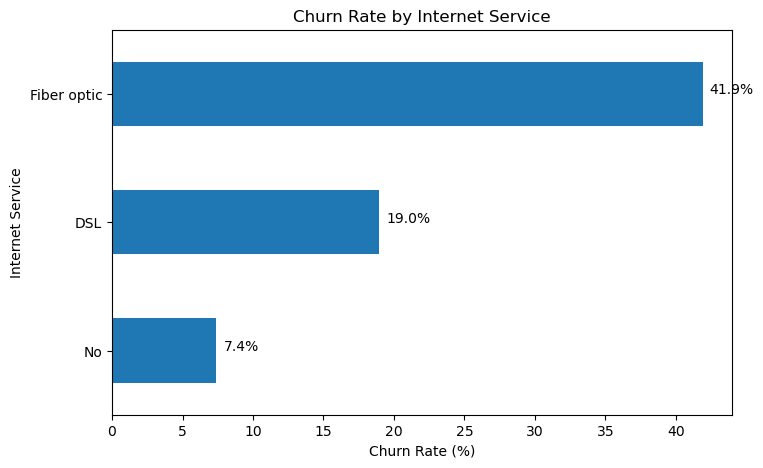

In [54]:
internet_churn = (
    pd.crosstab(
        df["Internet Service"],
        df["Churn Label"],
        normalize="index"
    ) * 100
)

ax = internet_churn["Yes"].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

for i, v in enumerate(internet_churn["Yes"].sort_values()):
    ax.text(v + 0.5, i, f"{v:.1f}%")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Churn Rate (%)")
plt.show()

## "Fiber optic customers are leaving at almost 2x the rate of DSL customers."


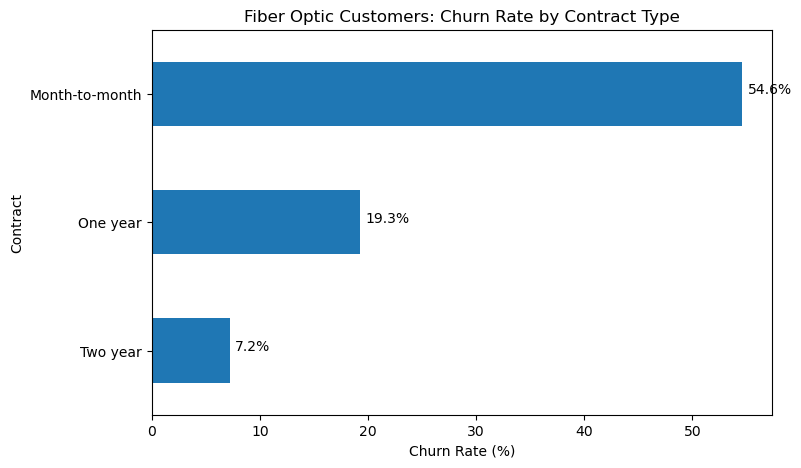

In [55]:
fiber_df = df[df["Internet Service"] == "Fiber optic"]

contract_fiber = (
    pd.crosstab(
        fiber_df["Contract"],
        fiber_df["Churn Label"],
        normalize="index"
    ) * 100
)

ax = contract_fiber["Yes"].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

for i, v in enumerate(contract_fiber["Yes"].sort_values()):
    ax.text(v + 0.5, i, f"{v:.1f}%")

plt.title("Fiber Optic Customers: Churn Rate by Contract Type")
plt.xlabel("Churn Rate (%)")
plt.show()

### Fiber Optic Customer Churn Analysis

Fiber Optic customers exhibited the highest overall churn rate (41.9%).

Further segmentation revealed that churn behavior was strongly influenced by contract type:

- Month-to-Month Fiber customers: 54.6% churn
- One-Year Fiber customers: 19.3% churn
- Two-Year Fiber customers: 7.2% churn

Key Finding:
The churn issue is concentrated within Fiber Optic customers who are on short-term contracts.

Business Recommendation:
Prioritize retention campaigns targeting Month-to-Month Fiber customers and incentivize migration to long-term plans.

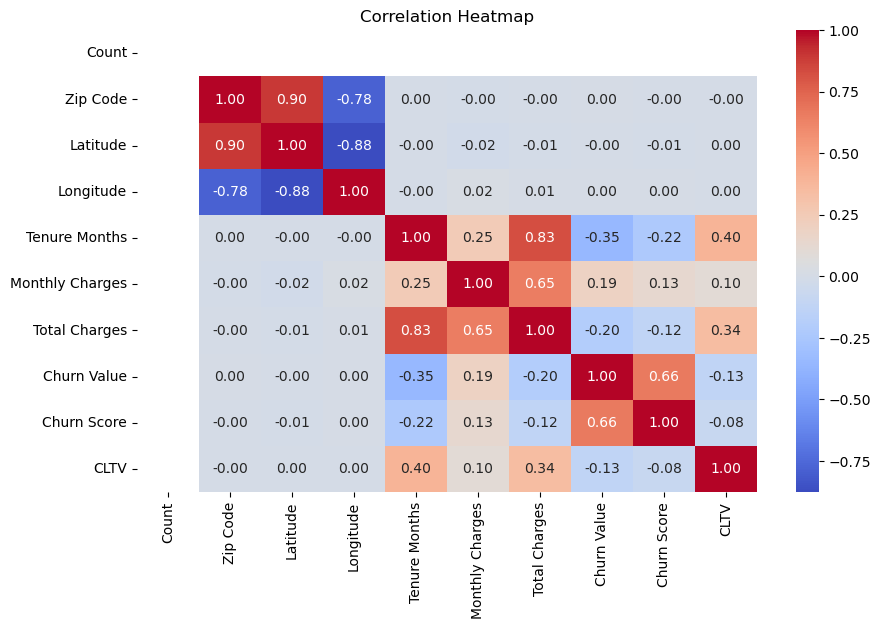

In [62]:
plt.figure(figsize=(10,6))

num_df = df.select_dtypes(
    include=["int64", "float64"]
)

corr_matrix = num_df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

<Axes: xlabel='Churn Label', ylabel='Monthly Charges'>

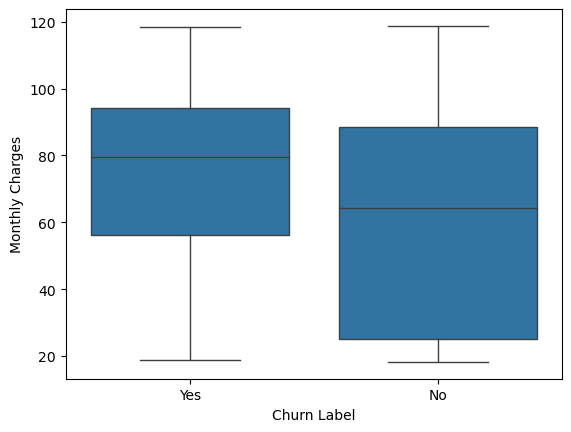

In [63]:
sns.boxplot(
    data=df,
    x="Churn Label",
    y="Monthly Charges"
)

### Monthly Charges vs Churn

- Customers who churn tend to have higher monthly charges.
- Median monthly charge for churned customers is significantly higher than retained customers.
- High pricing appears to be associated with increased churn risk.

Business Insight:
Customers paying premium monthly fees may have higher expectations and greater price sensitivity, making them more likely to switch providers.

Recommendation:
Target high-paying customers with retention offers, loyalty benefits, or premium support services.

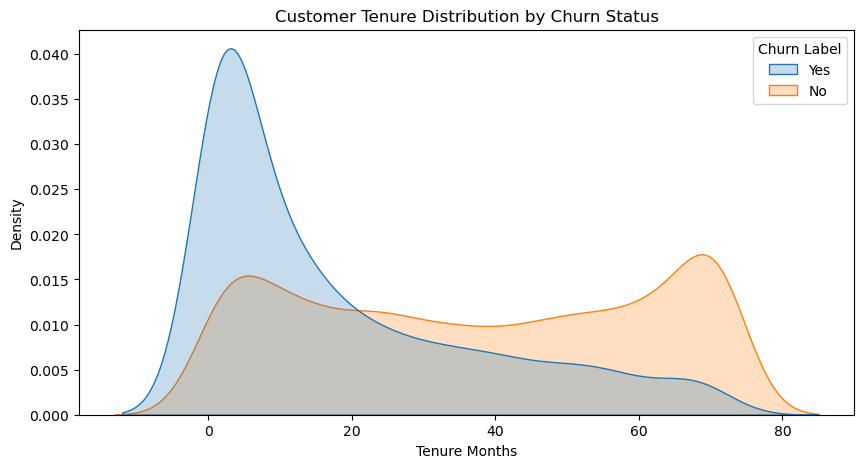

In [65]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    data=df,
    x="Tenure Months",
    hue="Churn Label",
    fill=True,
    common_norm=False
)

plt.title("Customer Tenure Distribution by Churn Status")
plt.show()

### Customer Tenure Analysis

- Churned customers are heavily concentrated in the early months of their tenure.
- Retained customers are concentrated in the 60–72 month tenure range.
- The probability of churn decreases as customer tenure increases.

Business Insight:
Customer loyalty strengthens significantly with tenure. Early-stage customers represent the highest-risk segment and should be prioritized for retention initiatives.

Recommendation:
Implement onboarding programs, proactive customer engagement, and retention campaigns during the first 12 months of the customer lifecycle.


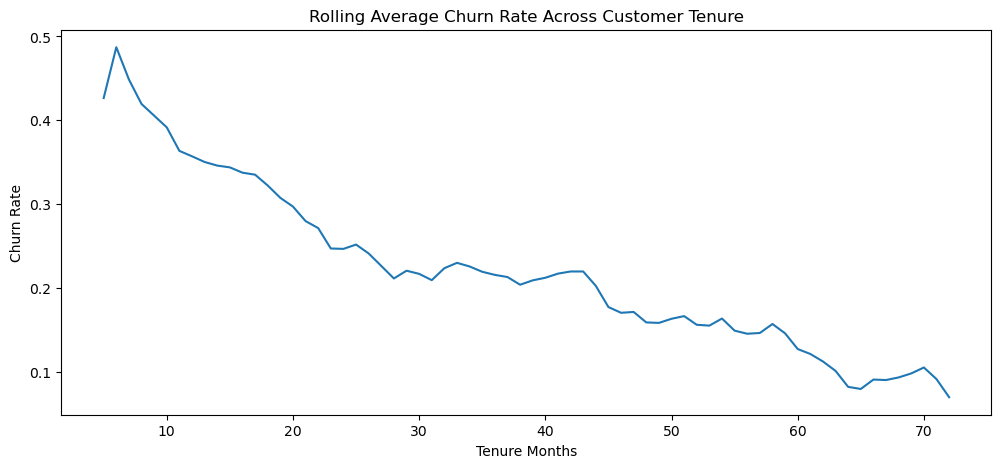

In [67]:
churn_by_tenure = (
    df.groupby("Tenure Months")["Churn Value"]
      .mean()
      .rolling(6)
      .mean()
      .reset_index()
)

plt.figure(figsize=(12,5))

sns.lineplot(
    data=churn_by_tenure,
    x="Tenure Months",
    y="Churn Value"
)

plt.title(
    "Rolling Average Churn Rate Across Customer Tenure"
)

plt.ylabel("Churn Rate")
plt.xlabel("Tenure Months")

plt.show()

Retention strategy should focus on customers
during their first year of service.
